# Tournament vs. lexicase selection

First comparison notebook â€” the template every later algorithm comparison in this repo follows
(see [docs/design/0003](../docs/design/0003-algorithm-landscape-and-roadmap.md), phase 2).

Both selection strategies live in `libs/evolve` (`evolve.selection`) and are used exactly as
they'd be used for a real run via `jobs/baseline_gp_run.py` â€” this notebook just runs the same
`evolve()` loop multiple times with different selection strategies and different random seeds,
and compares what comes out.

In [1]:
import random
import statistics

import matplotlib.pyplot as plt

from evolve import (
    LexicaseSelection,
    LinearCrossoverMutation,
    SymbolicRegressionFitness,
    TournamentSelection,
    evolve,
    random_program,
)

## The benchmark

Same fixed benchmark as `jobs/baseline_gp_run.py` â€” reused deliberately
(docs/design/0003 "fixed benchmark problems as an anchor") so results are comparable across
notebooks and runs, not just within this one. `x**4 - 3*x**2 + 2` is picked specifically because a
random individual can't stumble into a near-perfect answer by luck (a simpler target like `x**2`
could, with this instruction set) â€” both selection strategies should have real work to do.

In [2]:
TARGET = lambda x: x**4 - 3 * x**2 + 2
INPUTS = [i / 5 for i in range(-5, 6)]

POPULATION_SIZE = 60
NUM_INSTRUCTIONS = 12
NUM_REGISTERS = 4
GENERATIONS = 60
SEEDS = range(10)  # 10 independent runs per selection strategy, to see typical behavior, not one lucky/unlucky seed


def run_trial(selection, seed):
    rng = random.Random(seed)
    population = [
        random_program(NUM_INSTRUCTIONS, NUM_REGISTERS, num_inputs=1, rng=rng)
        for _ in range(POPULATION_SIZE)
    ]
    summaries = []
    evolve(
        population,
        fitness=SymbolicRegressionFitness(target=TARGET, inputs=INPUTS),
        selection=selection,
        variation=LinearCrossoverMutation(mutation_rate=0.1),
        generations=GENERATIONS,
        on_generation=[summaries.append],
        rng=rng,
    )
    return [s.best_fitness for s in summaries]


results = {
    "tournament": [run_trial(TournamentSelection(k=3), seed) for seed in SEEDS],
    "lexicase": [run_trial(LexicaseSelection(), seed) for seed in SEEDS],
}

## Convergence comparison

Mean best-fitness per generation across the 10 seeds, with a Â±1 std-dev band, for each selection
strategy. Higher (closer to 0) is better â€” fitness is `-squared_error`.

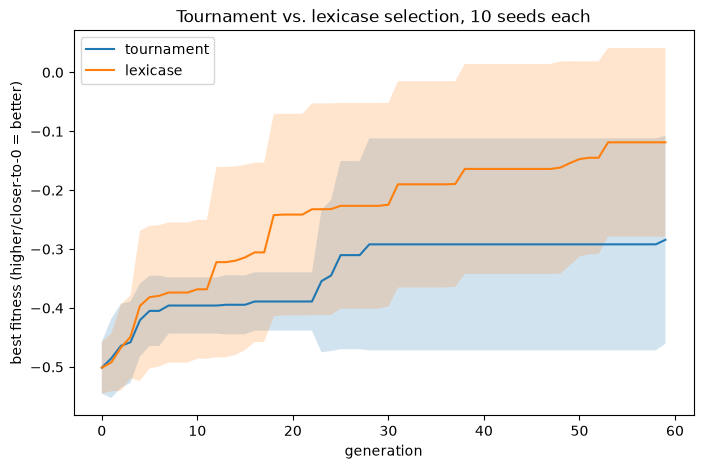

tournament: gen0 mean=-0.5013  final mean=-0.2842  final std=0.1765
  lexicase: gen0 mean=-0.5013  final mean=-0.1187  final std=0.1601


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, curves in results.items():
    by_gen = list(zip(*curves))  # transpose: [gen][seed] -> tuple of best_fitness across seeds
    means = [statistics.fmean(gen_values) for gen_values in by_gen]
    stds = [statistics.pstdev(gen_values) for gen_values in by_gen]
    generations = range(len(means))
    ax.plot(generations, means, label=name)
    ax.fill_between(
        generations,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        alpha=0.2,
    )

ax.set_xlabel("generation")
ax.set_ylabel("best fitness (higher/closer-to-0 = better)")
ax.set_title(f"Tournament vs. lexicase selection, {len(SEEDS)} seeds each")
ax.legend()
plt.show()

for name, curves in results.items():
    gen0 = statistics.fmean(c[0] for c in curves)
    final = statistics.fmean(c[-1] for c in curves)
    final_std = statistics.pstdev(c[-1] for c in curves)
    print(f"{name:>10}: gen0 mean={gen0:.4f}  final mean={final:.4f}  final std={final_std:.4f}")

On this benchmark, lexicase reaches a clearly better mean final fitness than tournament selection,
over the same 10 seeds, same population size, same variation operator â€” the only thing that
changed is how parents get picked. That's a real result, not a foregone conclusion: lexicase isn't
universally better, it's better *here*, on a smooth single-output regression problem where the 11
test cases are highly correlated (improving on one nearby x tends to improve neighboring x too),
which plays to lexicase's strength of not letting a population converge prematurely onto one
mediocre-everywhere strategy. Whether that holds on other problem shapes (discrete cases,
multi-objective, or a simulation-based fitness with genuinely independent sub-tasks) is exactly
the kind of question later comparisons in this notebook series should answer, not assume.

## Why: specialists vs. generalists

The mechanism behind that result, isolated from GP dynamics entirely â€” same synthetic example used
in `libs/evolve/tests/test_evolve.py`. Four "individuals", three test cases:

- `generalist`: mediocre but consistent on every case (fitness `5.0` everywhere) â€” the best **mean**
  fitness of the four.
- `specialist_a/b/c`: excellent (`10.0`) on exactly one case, terrible (`0.0`) on the other two.

Tournament selection (which reduces to mean fitness) should pick the generalist almost every time.
Lexicase, which never even computes a mean, should essentially never pick it â€” the generalist never
wins any single case outright, so it gets filtered out on the very first case examined, regardless
of which case that is.

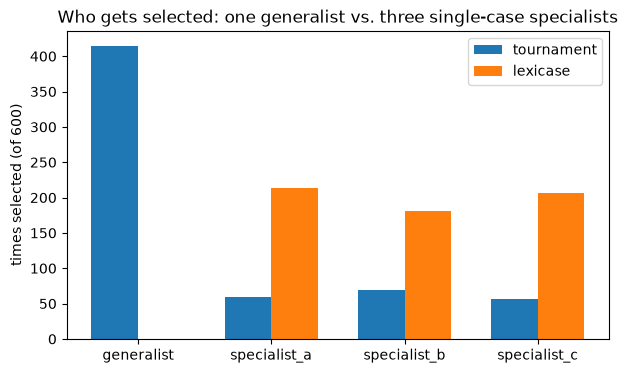

In [4]:
population = ["generalist", "specialist_a", "specialist_b", "specialist_c"]
case_fitnesses = [
    [5.0, 5.0, 5.0],
    [10.0, 0.0, 0.0],
    [0.0, 10.0, 0.0],
    [0.0, 0.0, 10.0],
]

trials = 600
rng = random.Random(3)
counts = {
    "tournament": {name: 0 for name in population},
    "lexicase": {name: 0 for name in population},
}
tournament = TournamentSelection(k=4)
lexicase = LexicaseSelection(epsilon=0.0)
for _ in range(trials):
    counts["tournament"][tournament.select(population, case_fitnesses, rng)] += 1
    counts["lexicase"][lexicase.select(population, case_fitnesses, rng)] += 1

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(population))
width = 0.35
ax.bar([i - width / 2 for i in x], [counts["tournament"][n] for n in population], width, label="tournament")
ax.bar([i + width / 2 for i in x], [counts["lexicase"][n] for n in population], width, label="lexicase")
ax.set_xticks(list(x))
ax.set_xticklabels(population)
ax.set_ylabel(f"times selected (of {trials})")
ax.set_title("Who gets selected: one generalist vs. three single-case specialists")
ax.legend()
plt.show()

## Takeaways

- Lexicase and tournament selection are both valid, both cheap to swap in behind the same
  `SelectionStrategy` interface â€” no genome or fitness-evaluator changes needed, exactly as
  docs/design/0003 predicted for this phase.
- The mechanism difference (mean-fitness vs. case-by-case filtering) has a real, measurable
  consequence: lexicase preserves specialists a generalist-favoring strategy would prune out, and
  on this benchmark that translated into faster convergence, not just "more diversity" as an
  abstract good.
- Next per docs/design/0003's roadmap: multi-objective (Pareto) selection, trading accuracy against
  program size â€” same template, same benchmark, a third strategy added to the comparison.